In [1]:
# 1. Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler, PowerTransformer
from sklearn.decomposition import PCA
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from scipy.stats.mstats import winsorize

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid") 

In [6]:
# 2. Load Data
df = pd.read_csv(r'C:\Users\zbook g6\Uni_project\ML_Uni_project\Data\weatherAUS.csv')
print(f"Dataset Shape: {df.shape}")
display(df.head(10))

Dataset Shape: (145460, 23)


,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,12/1/2008,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,12/2/2008,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,12/3/2008,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,12/4/2008,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,12/5/2008,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No
5,12/6/2008,Albury,14.6,29.7,0.2,NaN,NaN,WNW,56.0,W,...,55.0,23.0,1009.2,1005.4,NaN,NaN,20.6,28.9,No,No
6,12/7/2008,Albury,14.3,25.0,0.0,NaN,NaN,W,50.0,SW,...,49.0,19.0,1009.6,1008.2,1.0,NaN,18.1,24.6,No,No
7,12/8/2008,Albury,7.7,26.7,0.0,NaN,NaN,W,35.0,SSE,...,48.0,19.0,1013.4,1010.1,NaN,NaN,16.3,25.5,No,No
8,12/9/2008,Albury,9.7,31.9,0.0,NaN,NaN,NNW,80.0,SE,...,42.0,9.0,1008.9,1003.6,NaN,NaN,18.3,30.2,No,Yes
9,12/10/2008,Albury,13.1,30.1,1.4,NaN,NaN,W,28.0,S,...,58.0,27.0,1007.0,1005.7,NaN,NaN,20.1,28.2,Yes,No


In [9]:
display(df.tail())

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
145455,6/21/2017,Uluru,2.8,23.4,0.0,NaN,NaN,E,31.0,SE,...,51.0,24.0,1024.6,1020.3,NaN,NaN,10.1,22.4,No,No
145456,6/22/2017,Uluru,3.6,25.3,0.0,NaN,NaN,NNW,22.0,SE,...,56.0,21.0,1023.5,1019.1,NaN,NaN,10.9,24.5,No,No
145457,6/23/2017,Uluru,5.4,26.9,0.0,NaN,NaN,N,37.0,SE,...,53.0,24.0,1021.0,1016.8,NaN,NaN,12.5,26.1,No,No
145458,6/24/2017,Uluru,7.8,27.0,0.0,NaN,NaN,SE,28.0,SSE,...,51.0,24.0,1019.4,1016.5,3.0,2.0,15.1,26.0,No,No
145459,6/25/2017,Uluru,14.9,NaN,0.0,NaN,NaN,NaN,NaN,ESE,...,62.0,36.0,1020.2,1017.9,8.0,8.0,15.0,20.9,No,NaN


In [5]:
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145460 entries, 0 to 145459
Data columns (total 23 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           145460 non-null  object 
 1   Location       145460 non-null  object 
 2   MinTemp        143975 non-null  float64
 3   MaxTemp        144199 non-null  float64
 4   Rainfall       142199 non-null  float64
 5   Evaporation    82670 non-null   float64
 6   Sunshine       75625 non-null   float64
 7   WindGustDir    135134 non-null  object 
 8   WindGustSpeed  135197 non-null  float64
 9   WindDir9am     134894 non-null  object 
 10  WindDir3pm     141232 non-null  object 
 11  WindSpeed9am   143693 non-null  float64
 12  WindSpeed3pm   142398 non-null  float64
 13  Humidity9am    142806 non-null  float64
 14  Humidity3pm    140953 non-null  float64
 15  Pressure9am    130395 non-null  float64
 16  Pressure3pm    130432 non-null  float64
 17  Cloud9am       89572 non-null

None

In [10]:
display(df.describe())

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm
count,143975.000000,144199.000000,142199.000000,82670.000000,75625.000000,135197.000000,143693.000000,142398.000000,142806.000000,140953.000000,130395.00000,130432.000000,89572.000000,86102.000000,143693.000000,141851.00000
mean,12.194034,23.221348,2.360918,5.468232,7.611178,40.035230,14.043426,18.662657,68.880831,51.539116,1017.64994,1015.255889,4.447461,4.509930,16.990631,21.68339
std,6.398495,7.119049,8.478060,4.193704,3.785483,13.607062,8.915375,8.809800,19.029164,20.795902,7.10653,7.037414,2.887159,2.720357,6.488753,6.93665
min,-8.500000,-4.800000,0.000000,0.000000,0.000000,6.000000,0.000000,0.000000,0.000000,0.000000,980.50000,977.100000,0.000000,0.000000,-7.200000,-5.40000
25%,7.600000,17.900000,0.000000,2.600000,4.800000,31.000000,7.000000,13.000000,57.000000,37.000000,1012.90000,1010.400000,1.000000,2.000000,12.300000,16.60000
50%,12.000000,22.600000,0.000000,4.800000,8.400000,39.000000,13.000000,19.000000,70.000000,52.000000,1017.60000,1015.200000,5.000000,5.000000,16.700000,21.10000
75%,16.900000,28.200000,0.800000,7.400000,10.600000,48.000000,19.000000,24.000000,83.000000,66.000000,1022.40000,1020.000000,7.000000,7.000000,21.600000,26.40000
max,33.900000,48.100000,371.000000,145.000000,14.500000,135.000000,130.000000,87.000000,100.000000,100.000000,1041.00000,1039.600000,9.000000,9.000000,40.200000,46.70000


In [11]:
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df['Month'] = df['Date'].dt.month

In [13]:
df.head()

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow,Month
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No,12
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No,12
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No,12
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No,12
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No,12


Text(0.5, 1.0, 'Scatter Plot: MinTemp vs MaxTemp')

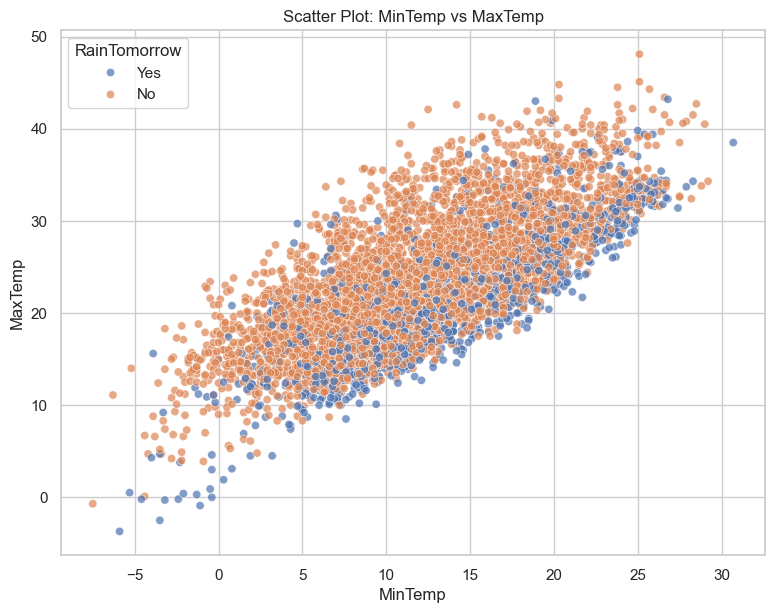

In [14]:
# 3. Data Visualization

plt.figure(figsize=(20, 15))

# 3.1 Scatter Plot
plt.subplot(2, 2, 1)
sample_df = df.sample(n=min(5000, len(df)), random_state=42)
sns.scatterplot(data=sample_df, x='MinTemp', y='MaxTemp', hue='RainTomorrow', alpha=0.7)
plt.title("Scatter Plot: MinTemp vs MaxTemp")




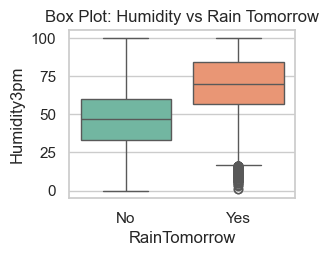

In [15]:
# 3.2 Box Plot
plt.subplot(2, 2, 2)
if 'Humidity3pm' in df.columns:
    sns.boxplot(data=df, x='RainTomorrow', y='Humidity3pm', palette='Set2')
    plt.title("Box Plot: Humidity vs Rain Tomorrow")

Text(0.5, 1.0, 'Line Plot: Average Max Temp by Month')

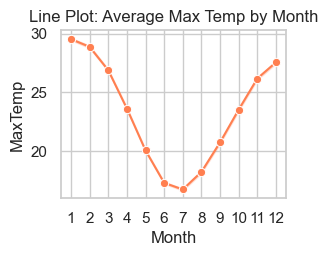

In [16]:
# 3.3 Line Plot
plt.subplot(2, 2, 3)
sns.lineplot(data=df, x='Month', y='MaxTemp', marker='o', color='coral')
plt.xticks(range(1, 13))
plt.title("Line Plot: Average Max Temp by Month")

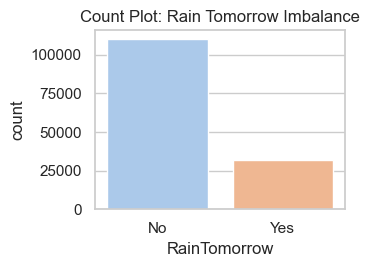

In [17]:
# 3.4 Count Plot
plt.subplot(2, 2, 4)
sns.countplot(data=df, x='RainTomorrow', palette='pastel')
plt.title("Count Plot: Rain Tomorrow Imbalance")

plt.tight_layout()
plt.show()

In [19]:
impute_method = 'Simple'
outlier_method = 'Clipping'
scaling_method = 'Standard'
sampling_method = 'UnderSampling'
use_pca = True

df_work = df.copy()

num_cols = df_work.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df_work.select_dtypes(include=['object']).columns.tolist()

print(f"Total Numerical columns: {len(num_cols)}")
print(f"Total Categorical columns: {len(cat_cols)}")

Total Numerical columns: 17
Total Categorical columns: 6


In [20]:
cat_imp = SimpleImputer(strategy='most_frequent')
df_work[cat_cols] = cat_imp.fit_transform(df_work[cat_cols])

if impute_method == 'KNN':
    print("Using KNN Imputer... (This might take a while)")
    num_imp = KNNImputer(n_neighbors=5)
else:
    print("Using Simple Imputer (Median)...")
    num_imp = SimpleImputer(strategy='median')
    
df_work[num_cols] = num_imp.fit_transform(df_work[num_cols])

print("Missing values remaining:", df_work.isnull().sum().sum())

Using Simple Imputer (Median)...
Missing values remaining: 0


In [21]:
if outlier_method == 'Winsorization':
    print("Applying Winsorization (Capping top and bottom 5%)...")
    for col in num_cols:
        df_work[col] = winsorize(df_work[col], limits=[0.05, 0.05])
else:
    print("Applying Clipping using IQR method...")
    for col in num_cols:
        Q1, Q3 = df_work[col].quantile(0.25), df_work[col].quantile(0.75)
        IQR = Q3 - Q1
        df_work[col] = df_work[col].clip(lower=Q1 - 1.5 * IQR, upper=Q3 + 1.5 * IQR)

print("Outliers handled successfully.")

Applying Clipping using IQR method...
Outliers handled successfully.


In [22]:
le = LabelEncoder()

for col in cat_cols:
    if df_work[col].nunique() == 2:
        df_work[col] = le.fit_transform(df_work[col])

remaining_cats = [c for c in cat_cols if df_work[c].nunique() > 2 and c != 'Date']
df_work = pd.get_dummies(df_work, columns=remaining_cats, drop_first=True)

print(f"Dataset shape after encoding: {df_work.shape}")
display(df_work.head(3))

Dataset shape after encoding: (145460, 113)


,Date,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,...,WindDir3pm_NNW,WindDir3pm_NW,WindDir3pm_S,WindDir3pm_SE,WindDir3pm_SSE,WindDir3pm_SSW,WindDir3pm_SW,WindDir3pm_W,WindDir3pm_WNW,WindDir3pm_WSW
0,2008-12-01,13.4,22.9,0.6,4.8,8.4,44.0,20.0,24.0,71.0,...,False,False,False,False,False,False,False,False,True,False
1,2008-12-02,7.4,25.1,0.0,4.8,8.4,44.0,4.0,22.0,44.0,...,False,False,False,False,False,False,False,False,False,True
2,2008-12-03,12.9,25.7,0.0,4.8,8.4,46.0,19.0,26.0,38.0,...,False,False,False,False,False,False,False,False,False,True


In [23]:
X = df_work.drop(['RainTomorrow', 'Date'], axis=1, errors='ignore')

if 'RainTomorrow' in df_work.columns:
    y = df_work['RainTomorrow']
    print("Target variable 'y' successfully separated.")
else:
    y = None
    print("Warning: Target variable 'RainTomorrow' not found.")
    
print(f"X shape: {X.shape}")

Target variable 'y' successfully separated.
X shape: (145460, 111)


In [24]:
if scaling_method == 'Standard':
    print("Applying StandardScaler...")
    X_scaled_array = StandardScaler().fit_transform(X)
elif scaling_method == 'MinMax':
    print("Applying MinMaxScaler...")
    X_scaled_array = MinMaxScaler().fit_transform(X)
else:
    print("Applying PowerTransformer...")
    X_scaled_array = PowerTransformer().fit_transform(X)

X_scaled = pd.DataFrame(X_scaled_array, columns=X.columns)

display(X_scaled.head(3))

Applying StandardScaler...


,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,...,WindDir3pm_NNW,WindDir3pm_NW,WindDir3pm_S,WindDir3pm_SE,WindDir3pm_SSE,WindDir3pm_SSW,WindDir3pm_SW,WindDir3pm_W,WindDir3pm_WNW,WindDir3pm_WSW
0,0.189751,-0.045242,0.358714,0.033745,-0.033731,0.357816,0.708308,0.641629,0.109440,-1.443652,...,-0.239163,-0.25083,-0.270622,-0.339915,-0.262829,-0.243723,-0.262156,-0.273304,3.923226,-0.264604
1,-0.752982,0.266030,-0.627098,0.033745,-0.033731,0.357816,-1.161737,0.404729,-1.334095,-1.297105,...,-0.239163,-0.25083,-0.270622,-0.339915,-0.262829,-0.243723,-0.262156,-0.273304,-0.254892,3.779236
2,0.111190,0.350922,-0.627098,0.033745,-0.033731,0.522075,0.591430,0.878529,-1.654880,-1.052860,...,-0.239163,-0.25083,-0.270622,-0.339915,-0.262829,-0.243723,-0.262156,-0.273304,-0.254892,3.779236


In [25]:
if y is not None:
    if sampling_method == 'SMOTE':
        print("Applying SMOTE for balancing...")
        sampler = SMOTE(random_state=42)
    else:
        print("Applying RandomUnderSampler for balancing...")
        sampler = RandomUnderSampler(random_state=42)
        
    X_res, y_final = sampler.fit_resample(X_scaled, y)
    print(f"Shape after balancing: X={X_res.shape}, y={y_final.shape}")
    
    if use_pca:
        print("Applying PCA (Reducing to 10 Components)...")
        pca = PCA(n_components=10)
        X_final_array = pca.fit_transform(X_res)
        
        pca_columns = [f'PC{i+1}' for i in range(10)]
        X_final = pd.DataFrame(X_final_array, columns=pca_columns)
    else:
        X_final = X_res
        
    print("\n✅ --- Preprocessing Pipeline Completed! ---")
    print(f"Final Features Shape: {X_final.shape}")
    display(X_final.head())

Applying RandomUnderSampler for balancing...
Shape after balancing: X=(63754, 111), y=(63754,)
Applying PCA (Reducing to 10 Components)...

✅ --- Preprocessing Pipeline Completed! ---
Final Features Shape: (63754, 10)


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10
0,0.133243,0.875775,1.624768,-0.537394,0.722757,-0.767421,0.511711,-0.349029,1.356618,2.372012
1,4.036190,-0.029623,1.517660,1.575819,1.359677,-1.124211,-0.252585,0.329243,1.347283,-1.335348
2,-0.223407,1.595762,3.432576,0.172642,-2.759125,1.251470,1.984681,1.606887,1.126719,-0.384740
3,1.712415,1.737232,0.957291,-1.658568,-1.017478,0.122678,-0.145534,0.551978,-0.679557,-0.401237
4,-0.749073,-0.004325,-2.042394,0.675282,0.081835,0.238554,-0.500406,0.994130,1.901363,-0.512370


In [30]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_final, y_final, test_size=0.2, random_state=42)

print(f"Training Data: X={X_train.shape}, y={y_train.shape}")
print(f"Testing Data: X={X_test.shape}, y={y_test.shape}")

Training Data: X=(51003, 10), y=(51003,)
Testing Data: X=(12751, 10), y=(12751,)


In [34]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'class_weight': ['balanced', 'balanced_subsample'] 
}
rf = RandomForestClassifier(random_state=42)

random_search = RandomizedSearchCV(estimator=rf, param_distributions=param_dist, 
                                   n_iter=10, cv=3, random_state=42, n_jobs=-1, verbose=2)

print("Searching for best parameters...")
random_search.fit(X_train, y_train)

print(f"Best Parameters: {random_search.best_params_}")

best_rf = random_search.best_estimator_
y_pred_best = best_rf.predict(X_test)



Searching for best parameters...
Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best Parameters: {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_depth': 30, 'class_weight': 'balanced_subsample'}
⭐ New Model Accuracy: 77.14%


⭐ Model Accuracy: 77.05%

📊 Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.76      0.77      6328
           1       0.77      0.78      0.77      6423

    accuracy                           0.77     12751
   macro avg       0.77      0.77      0.77     12751
weighted avg       0.77      0.77      0.77     12751

🔲 Confusion Matrix:


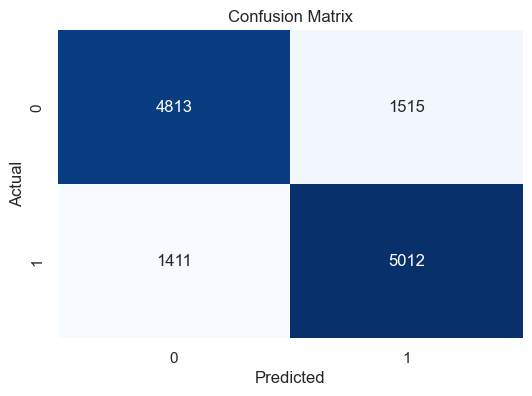

In [37]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

accuracy = accuracy_score(y_test, y_pred)
print(f"⭐ Model Accuracy: {accuracy * 100:.2f}%\n")

print("📊 Classification Report:")
print(classification_report(y_test, y_pred))

print("🔲 Confusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

Training Logistic Regression model... (This is usually very fast)
✅ Logistic Regression trained successfully!
⭐ Logistic Regression Accuracy: 75.67%

📊 Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.77      0.76      6328
           1       0.77      0.74      0.75      6423

    accuracy                           0.76     12751
   macro avg       0.76      0.76      0.76     12751
weighted avg       0.76      0.76      0.76     12751

🔲 Confusion Matrix:


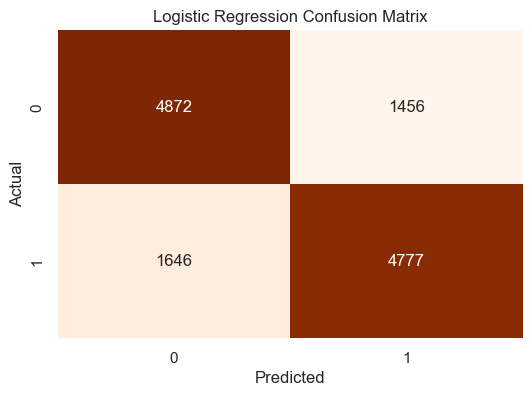

In [38]:
from sklearn.linear_model import LogisticRegression
log_reg = LogisticRegression(random_state=42, max_iter=1000)

print("Training Logistic Regression model... (This is usually very fast)")
log_reg.fit(X_train, y_train)
print("✅ Logistic Regression trained successfully!")

y_pred_log = log_reg.predict(X_test)

accuracy_log = accuracy_score(y_test, y_pred_log)
print(f"⭐ Logistic Regression Accuracy: {accuracy_log * 100:.2f}%\n")

print("📊 Classification Report:")
print(classification_report(y_test, y_pred_log))

print("🔲 Confusion Matrix:")
cm_log = confusion_matrix(y_test, y_pred_log)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_log, annot=True, fmt='d', cmap='Oranges', cbar=False)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Logistic Regression Confusion Matrix')
plt.show()

Training XGBoost model... (This might take a minute)
✅ XGBoost trained successfully!
⭐ XGBoost Accuracy: 76.83%

📊 Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.76      0.76      6328
           1       0.76      0.78      0.77      6423

    accuracy                           0.77     12751
   macro avg       0.77      0.77      0.77     12751
weighted avg       0.77      0.77      0.77     12751

🔲 Confusion Matrix:


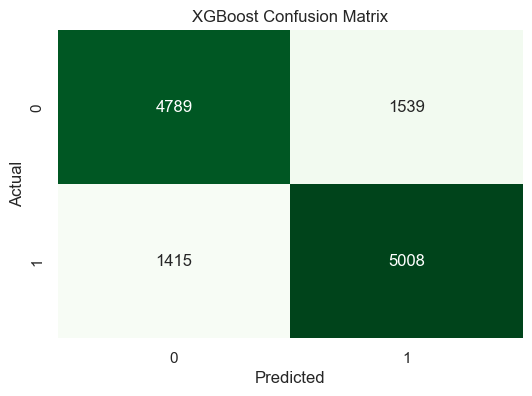

In [39]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# 1. تعريف وتدريب الموديل
# استخدمنا n_estimators و learning_rate كبداية ممتازة لرفع الدقة
xgb_model = XGBClassifier(
    n_estimators=200, 
    learning_rate=0.1, 
    max_depth=6, 
    random_state=42, 
    eval_metric='logloss'
)

print("Training XGBoost model... (This might take a minute)")
xgb_model.fit(X_train, y_train)
print("✅ XGBoost trained successfully!")

# 2. التوقع
y_pred_xgb = xgb_model.predict(X_test)

# 3. التقييم وعرض النتائج
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
print(f"⭐ XGBoost Accuracy: {accuracy_xgb * 100:.2f}%\n")

print("📊 Classification Report:")
print(classification_report(y_test, y_pred_xgb))

print("🔲 Confusion Matrix:")
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Greens', cbar=False)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('XGBoost Confusion Matrix')
plt.show()